## CLASSIFICATION ON HEART DISEASE

In [75]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import os
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os 
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [76]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [77]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [78]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [80]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [81]:
X = df.iloc[:,0:13]
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [82]:
Y = df.iloc[:,-1]
Y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [83]:
X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [84]:
X_train.shape

(820, 13)

In [85]:
X_test.shape

(205, 13)

In [86]:
df['target'].unique()

array([0, 1], dtype=int64)

In [87]:
labels = ['Normal', 'Attack']
labels

['Normal', 'Attack']

In [88]:
le = LabelEncoder()
labels = le.fit_transform(labels)

In [89]:
precision = []
recall = []
fscore = []
accuracy = []

In [90]:
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')

    p = precision_score(testY, predict, average='macro') * 100
    r = recall_score(testY, predict, average='macro') * 100
    f = f1_score(testY, predict, average='macro') * 100
    a = accuracy_score(testY, predict) * 100

    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)

    print(algorithm + ' Accuracy : ' + str(a))
    print(algorithm + ' Precision : ' + str(p))
    print(algorithm + ' Recall : ' + str(r))
    print(algorithm + ' FScore : ' + str(f))

    # Generate the report BEFORE printing it
    report = classification_report(
    testY,
    predict,
    target_names=[str(x) for x in labels],
    zero_division=0
)


    print('\n' + algorithm + ' classification report\n')
    print(report)

    conf_matrix = confusion_matrix(testY, predict)

    plt.figure(figsize=(5, 5))

    ax = sns.heatmap(
        conf_matrix,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        cmap='Purples',
        fmt='g'
    )

    ax.set_ylim([0, len(labels)])

    plt.title(algorithm + ' Confusion Matrix')
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()


## 2 Knearest Neighbours Classifier

KNN Classifier Accuracy : 98.53658536585365
KNN Classifier Precision : 98.57142857142858
KNN Classifier Recall : 98.54368932038835
KNN Classifier FScore : 98.53644606268294

KNN Classifier classification report

              precision    recall  f1-score   support

           1       0.97      1.00      0.99       102
           0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



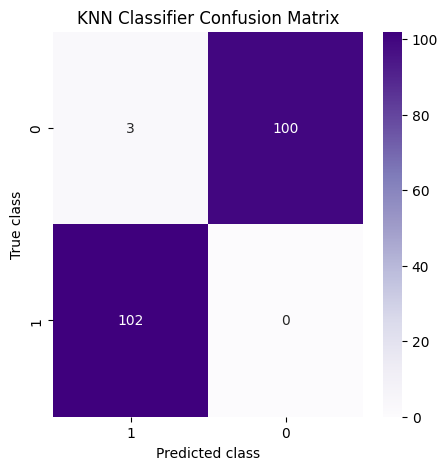

In [91]:
if os.path.exists('KNN_weights.pkl'):
    classifier = joblib.load('KNN_weights.pkl')
    predict = classifier.predict(X_test)
    calculateMetrics("KNN Classifier",predict,Y_test)
else:
    classifier = KNeighborsClassifier(weights = 'distance',algorithm = 'ball_tree',leaf_size = 2, p = 1)
    classifier.fit(X_train , Y_train)
    predict = classifier.predict(X_test)
    joblib.dump(classifier,'KNN_weights.pkl')
    print("KNN classifier_model trained and model weights saved.")
    calculateMetrics("KNeighborsClassifier",predict , Y_test)

## Random Forest Algorithm

Random Forest Classifier Accuracy : 98.53658536585365
Random Forest Classifier Precision : 98.57142857142858
Random Forest Classifier Recall : 98.54368932038835
Random Forest Classifier FScore : 98.53644606268294

Random Forest Classifier classification report

              precision    recall  f1-score   support

           1       0.97      1.00      0.99       102
           0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



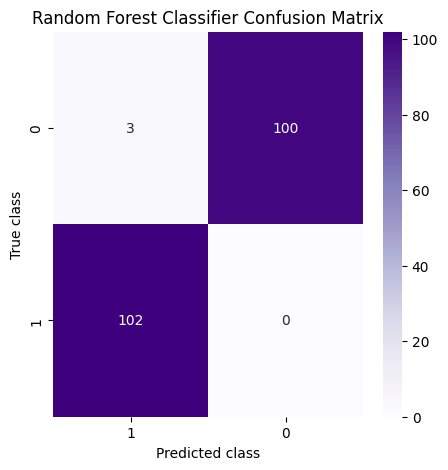

In [92]:
if os.path.exists('RandomForest_weights.pkl'):
    classifier = joblib.load('RandomForest_weights.pkl')
    predict = classifier.predict(X_test)
    calculateMetrics("Random Forest Classifier", predict, Y_test)
else:
    classifier = RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
    
    classifier.fit(X_train, Y_train)
    predict = classifier.predict(X_test)
    joblib.dump(classifier, 'RandomForest_weights.pkl')
    
    print("Random Forest classifier_model trained and model weights saved.")
    calculateMetrics("Random Forest Classifier", predict, Y_test)


## LogisticRegression

Logistic Regression Accuracy : 78.04878048780488
Logistic Regression Precision : 79.05392060043452
Logistic Regression Recall : 78.00304587854558
Logistic Regression FScore : 77.83783783783784

Logistic Regression classification report

              precision    recall  f1-score   support

           1       0.84      0.69      0.76       102
           0       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



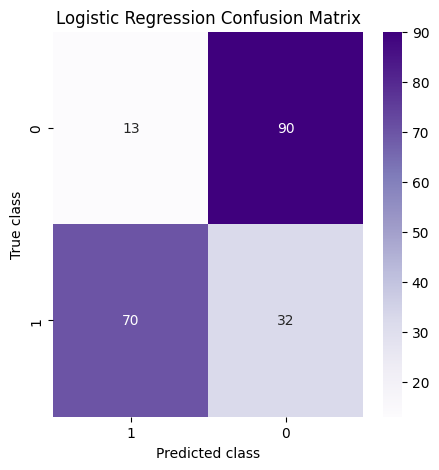

In [93]:
if os.path.exists('LogisticRegression_weights.pkl'):
    classifier = joblib.load('LogisticRegression_weights.pkl')
    predict = classifier.predict(X_test)
    calculateMetrics("Logistic Regression", predict, Y_test)
else:
    classifier = LogisticRegression()
    classifier.fit(X_train , Y_train)
    predict = classifier.predict(X_test)
    joblib.dump(classifier,'LogisticRegression_weights.pkl')
    print("Logistic Regression classifier_model trained and model weights saved.")
    calculateMetrics("LogisticRegression",predict,Y_test)

## GAUSSION NAIVE BAYES

Gaussion Navie Bayes Accuracy : 80.0
Gaussion Navie Bayes Precision : 81.0784120086905
Gaussion Navie Bayes Recall : 79.95431182181612
Gaussion Navie Bayes FScore : 79.8078078078078

Gaussion Navie Bayes classification report

              precision    recall  f1-score   support

           1       0.87      0.71      0.78       102
           0       0.75      0.89      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



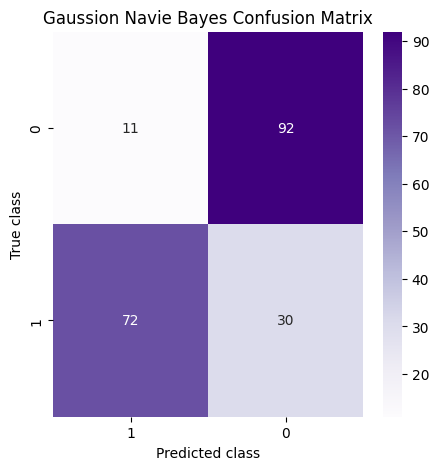

In [94]:
if os.path.exists('GaussionNB_weights.pkl'):
    classifier = joblib.load('GaussionNB_weights.pkl')
    predict = classifier.predict(X_test)
    calculateMetrics("Gaussion Navie Bayes", predict,Y_test)
else:
    classifier = GaussianNB()
    classifier.fit(X_train,Y_train)
    predict = classifier.predict(X_test)
    joblib.dump(classifier,'GaussionNB_weights.pkl')
    print("Gaussion Navie Bayes classifier_model trained and model weights saved.")
    calculateMetrics("GaussionNB",predict,Y_test)

## Decision Tree Classifier

Decision Tree classifier_model trained and model weights saved.
DecisionTreeClassifier Accuracy : 98.53658536585365
DecisionTreeClassifier Precision : 98.57142857142858
DecisionTreeClassifier Recall : 98.54368932038835
DecisionTreeClassifier FScore : 98.53644606268294

DecisionTreeClassifier classification report

              precision    recall  f1-score   support

           1       0.97      1.00      0.99       102
           0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



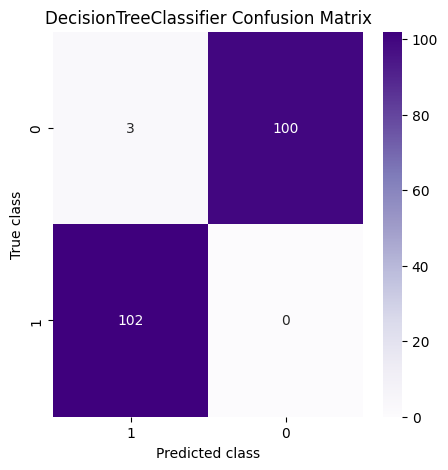

In [95]:
if os.path.exists('DecisionTree_weights.pkl'):
    classifier = joblib.load('DecisionTree_weights.pkl')
    predict = classifier.predict(X_test)
    calculateMetrics("Decision Tree Classifier", predict , Y_test)
else:
    classifier = DecisionTreeClassifier()
    classifier.fit(X_train, Y_train)
    predict = classifier.predict(X_test)
    joblib.dump(classifier,'DecisionTree_weights.pkl')
    print("Decision Tree classifier_model trained and model weights saved.")
    calculateMetrics("DecisionTreeClassifier",predict,Y_test)